<a href="https://colab.research.google.com/github/devayyan137/ARCH-Technologies---Machine-Learning-Internship-Tasks/blob/main/Task_1_Email_Spam_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [46]:
from google.colab import files
uploaded = files.upload()


Saving spam.csv to spam (2).csv


In [47]:
import pandas as pd
df = pd.read_csv("spam.csv", encoding="latin1")
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2802,spam,FreeMsg>FAV XMAS TONES!Reply REAL,NaN,NaN,NaN
4855,ham,yes baby! I need to stretch open your pussy!,NaN,NaN,NaN
3696,spam,You are a winner you have been specially selec...,NaN,NaN,NaN
4108,ham,I want to lick your pussy now...,NaN,NaN,NaN
2906,ham,ALRITE,NaN,NaN,NaN


In [48]:
shape=df.shape
print(shape)
df.info()

(5572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [49]:
df.rename(columns={'v1':'label','v2':'text'},inplace=True)
df.sample(5)

,label,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
4898,ham,"Haha, that was the first person I was gonna ask",NaN,NaN,NaN
1098,ham,NO GIFTS!! You trying to get me to throw mysel...,NaN,NaN,NaN
2518,ham,Joy's father is John. Then John is the NAME of...,NaN,NaN,NaN
109,ham,Dont worry. I guess he's busy.,NaN,NaN,NaN
4455,ham,If you want to mapquest it or something look u...,"that's the tiny street where the parking lot is""",NaN,NaN


In [50]:
df.isnull().sum()



,0
label,0
text,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [51]:
df.duplicated().sum()


np.int64(403)

In [52]:
df.drop_duplicates(keep='first')

,label,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [53]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['label'] = le.fit_transform(df['label'])
df.head()

,label,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [55]:
df['label'].value_counts()

,count
label,
0,4825
1,747


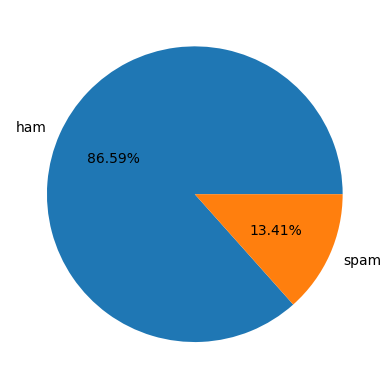

<Axes: xlabel='label', ylabel='Count'>

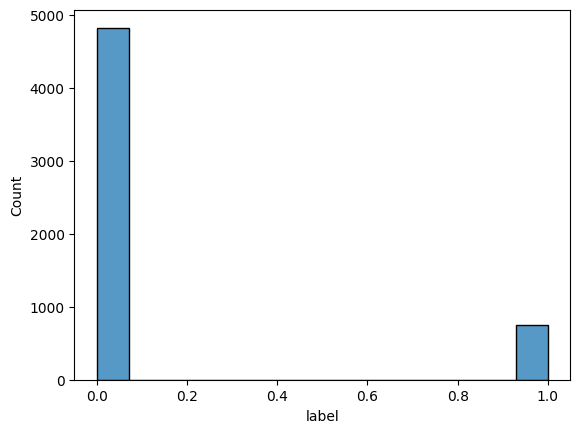

In [54]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(),autopct='%0.2f%%',labels=['ham','spam'])
plt.show()
import seaborn as sns
sns.histplot(df['label'])


 Model Performance
Accuracy: 96.8609865470852

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



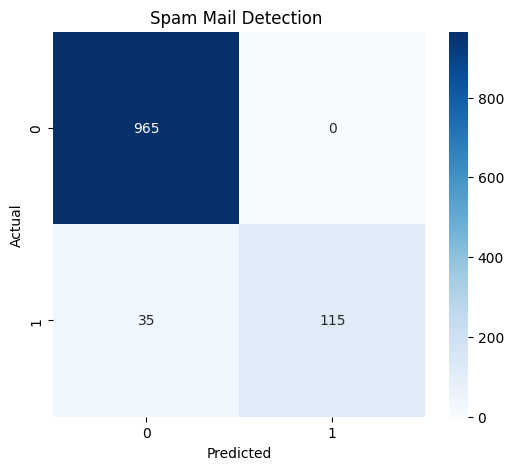


Example Test:
SPAM


In [56]:
tfidf = TfidfVectorizer(stop_words='english', lowercase=True)
X = tfidf.fit_transform(df['text'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\n Model Performance")
accuracy = accuracy_score(y_test, y_pred) * 100
print("Accuracy:", accuracy, )
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Spam Mail Detection ')
plt.show()

def predict_email(msg):
    msg_tfidf = tfidf.transform([msg])
    prediction = model.predict(msg_tfidf)
    return "SPAM" if prediction[0] == 1 else "NOT SPAM"

print("\nExample Test:")
print(predict_email("You won 1000$."))